Import libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import re

In [30]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [4]:
np.random.seed(3)

## Data Preparation

#### Exploratory Data Analysis

In [5]:
holc = pd.read_csv('seattle_tracts_holc.csv')
holc.head(5)

,GEOID,pct_holc_A,pct_holc_B,pct_holc_C,pct_holc_D,pct_holc_graded,holc_dominant_grade,holc_grade_score
0,53033005304,0.00000,4.483842e-01,0.000000,0.000000,0.448384,B,2.000000
1,53033005901,0.00000,1.365832e-01,0.284780,0.000000,0.421364,C,2.675854
2,53033005401,0.00000,3.948537e-07,0.030135,0.131897,0.162032,D,3.814013
3,53033010102,0.03148,1.978415e-01,0.171302,0.000000,0.400623,B,2.349012
4,53033000602,0.00000,0.000000e+00,0.000000,0.000000,0.000000,ungraded,NaN


In [6]:
holc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   GEOID                181 non-null    int64  
 1   pct_holc_A           181 non-null    float64
 2   pct_holc_B           181 non-null    float64
 3   pct_holc_C           181 non-null    float64
 4   pct_holc_D           181 non-null    float64
 5   pct_holc_graded      181 non-null    float64
 6   holc_dominant_grade  181 non-null    object 
 7   holc_grade_score     141 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 11.4+ KB


In [7]:
parcels = pd.read_csv('seattle_parcels_with_tract.csv', low_memory = False)
parcels.head(5)

,Major,Minor,CurrentZoning,SqFtLot,NbrLivingUnits,ZipCode,Stories,BldgGrade,SqFtTotLiving,SqFtGarageAttached,Bedrooms,BathFullCount,YrBuilt,YrRenovated,Condition,ApprLandVal,ApprImpsVal,TaxableLandVal,TaxableImpsVal,GEOID
0,982870,2753,LR3 (M1),500,1.0,98122,3.0,8.0,1080.0,0.0,2.0,2.0,2021.0,0.0,3.0,340000.0,280000.0,340000.0,280000.0,53033007700
1,57900,1110,NR3,6322,1.0,98117,1.0,8.0,2320.0,230.0,3.0,1.0,1954.0,0.0,3.0,615000.0,390000.0,615000.0,390000.0,53033001600
2,287710,4110,NC2-55 (M),3960,1.0,98103,1.5,7.0,1780.0,0.0,4.0,1.0,1925.0,0.0,3.0,0.0,300.0,0.0,0.0,53033002900
3,287710,4110,NC2-55 (M),3960,1.0,98103,1.5,7.0,1780.0,0.0,4.0,1.0,1925.0,0.0,3.0,1279000.0,700.0,376000.0,128900.0,53033002900
4,390410,230,NR3,6750,1.0,98118,1.0,6.0,660.0,0.0,2.0,1.0,1918.0,0.0,3.0,308000.0,150000.0,308000.0,150000.0,53033011101


In [8]:
acs = pd.read_csv('acs_tract_clean.csv')
acs.head(5)

,tractID,Median household income in the past 12 months (in 2024 inflation-adjusted dollars),Total:_x,Owner occupied,Renter occupied,Total:_y,White alone,Black or African American alone,American Indian and Alaska Native alone,Asian alone,...,pct_black,pct_asian,pct_amer_indian,pct_pacific_isl,pct_other_race,pct_two_plus_race,pct_renter_cost_burdened,pct_renter_severely_burdened,TRACTCE,GEOID
0,1.01,69577.0,1746,141,1605,3417,1693,652,0,422,...,0.190811,0.123500,0.000000,0.000000,0.038338,0.151888,0.443614,0.183178,101,53033000101
1,1.02,89840.0,2358,840,1518,4321,3121,362,0,431,...,0.083777,0.099745,0.000000,0.000000,0.052303,0.041888,0.563900,0.210804,102,53033000102
2,2.01,88833.0,2486,1269,1217,4953,2594,356,41,980,...,0.071876,0.197860,0.008278,0.000000,0.123360,0.074904,0.589154,0.171734,201,53033000201
3,2.02,138472.0,1549,1131,418,4404,2165,374,6,708,...,0.084923,0.160763,0.001362,0.000000,0.077203,0.184151,0.456938,0.358852,202,53033000202
4,3.00,135536.0,1201,865,336,2926,1797,179,11,612,...,0.061176,0.209159,0.003759,0.000342,0.007861,0.103554,0.324405,0.122024,300,53033000300


In [9]:
df = pd.merge(parcels, acs, on = 'GEOID', how = 'left')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193074 entries, 0 to 193073
Data columns (total 59 columns):
 #   Column                                                                              Non-Null Count   Dtype  
---  ------                                                                              --------------   -----  
 0   Major                                                                               193074 non-null  int64  
 1   Minor                                                                               193074 non-null  int64  
 2   CurrentZoning                                                                       193074 non-null  object 
 3   SqFtLot                                                                             193074 non-null  int64  
 4   NbrLivingUnits                                                                      163499 non-null  float64
 5   ZipCode                                                                             14

In [10]:
df = pd.merge(df, holc, on = 'GEOID', how = 'left')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193074 entries, 0 to 193073
Data columns (total 66 columns):
 #   Column                                                                              Non-Null Count   Dtype  
---  ------                                                                              --------------   -----  
 0   Major                                                                               193074 non-null  int64  
 1   Minor                                                                               193074 non-null  int64  
 2   CurrentZoning                                                                       193074 non-null  object 
 3   SqFtLot                                                                             193074 non-null  int64  
 4   NbrLivingUnits                                                                      163499 non-null  float64
 5   ZipCode                                                                             14

In [11]:
# How many of each HOLC grade do we have?
df['holc_dominant_grade'].value_counts()

holc_dominant_grade
B           75045
C           45421
ungraded    34540
D           28137
A            9931
Name: count, dtype: int64

In [12]:
# Drop the ungraded rows since we're comparing current data to HOLC grades
df_grades = df[df['holc_dominant_grade'] != 'ungraded']
df_grades['holc_dominant_grade'].value_counts()

holc_dominant_grade
B    75045
C    45421
D    28137
A     9931
Name: count, dtype: int64

In [13]:
# Drop columns that identify the tract
df_col = df_grades.drop(columns = ['Major', 'Minor', 'GEOID', 'tractID', 'TRACTCE'])
df_col.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158534 entries, 0 to 193072
Data columns (total 61 columns):
 #   Column                                                                              Non-Null Count   Dtype  
---  ------                                                                              --------------   -----  
 0   CurrentZoning                                                                       158534 non-null  object 
 1   SqFtLot                                                                             158534 non-null  int64  
 2   NbrLivingUnits                                                                      134138 non-null  float64
 3   ZipCode                                                                             120695 non-null  object 
 4   Stories                                                                             134138 non-null  float64
 5   BldgGrade                                                                           134138 

In [14]:
# Drop all other HOLC columns because of multicollinearity
df_no_holc = df_col.drop(columns = ['pct_holc_A', 'pct_holc_B', 'pct_holc_C', 'pct_holc_D', 'pct_holc_graded', 'holc_grade_score'])
df_no_holc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158534 entries, 0 to 193072
Data columns (total 55 columns):
 #   Column                                                                              Non-Null Count   Dtype  
---  ------                                                                              --------------   -----  
 0   CurrentZoning                                                                       158534 non-null  object 
 1   SqFtLot                                                                             158534 non-null  int64  
 2   NbrLivingUnits                                                                      134138 non-null  float64
 3   ZipCode                                                                             120695 non-null  object 
 4   Stories                                                                             134138 non-null  float64
 5   BldgGrade                                                                           134138 

In [15]:
# How many zip codes do we have?
df_no_holc['ZipCode'].value_counts()

ZipCode
98118         11817
98115         11813
98103         10144
98117          9221
98144          7217
98116          6627
98105          6450
98199          6346
98106          6202
98122          5952
98126          5797
98112          5779
98107          5739
98108          5352
98136          5017
98119          3764
98178          2316
98109          2221
98102          1846
98146           935
98125            93
98134            12
98177             3
98114             2
98104             2
98121             2
90108             1
98136-1728        1
98118-6116        1
sq                1
98018             1
98301             1
3                 1
98015             1
# 2               1
988122            1
98115-7942        1
# 3               1
98000             1
98199-3014        1
91844             1
0                 1
98013             1
98132             1
98103-8173        1
98                1
98118-3167        1
D1 south          1
98107-5353        1
981182019   

In [16]:
# Will dropping ZipCode change the proportion of the HOLC grades?
df_no_holc['holc_dominant_grade'].value_counts(normalize = True)

holc_dominant_grade
B    0.473368
C    0.286506
D    0.177482
A    0.062643
Name: proportion, dtype: float64

In [17]:
df_no_zip = df_no_holc.drop(columns = ['ZipCode'])
df_no_zip['holc_dominant_grade'].value_counts(normalize = True)

holc_dominant_grade
B    0.473368
C    0.286506
D    0.177482
A    0.062643
Name: proportion, dtype: float64

Drop zip code because it has a lot of null values, cleaning would result in even more null values, 
it doesn't change the grade proportions, and geographic location may be too close to HOLC grades.

In [18]:
# Will dropping rows with null values change the proportion of HOLC grades?
df_dropNaN = df_no_zip.dropna()
df_dropNaN['holc_dominant_grade'].value_counts(normalize = True)

holc_dominant_grade
B    0.512512
C    0.283535
D    0.164488
A    0.039465
Name: proportion, dtype: float64

In [19]:
# Compare actual numbers
df_dropNaN['holc_dominant_grade'].value_counts()

holc_dominant_grade
B    66049
C    36540
D    21198
A     5086
Name: count, dtype: int64

Numbers from earlier:   
holc_dominant_grade  
B    75045  
C    45421  
D    28137  
A     9931

Dropping all the rows with null values would change the percentage of the HOLC grades in the data set. 
Instead, create indicator columns for columns with missing values to note whether the value was missing and fill in nulls with an impossible value (-1) as a placeholder.

In [20]:
# Copy dataframe
df_clean = df_no_zip.copy()

In [21]:
for col in df_clean.select_dtypes(include = ['float64']).columns:
    if df_clean[col].isnull().any():
        # Create indicator column (1 = missing, 0 = real value)
        df_clean[f'{col}_is_missing'] = df_clean[col].isnull().astype(int)

        # Fill empty spaces with -1 placeholder
        df_clean[col] = df_clean[col].fillna(-1)

In [22]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158534 entries, 0 to 193072
Data columns (total 81 columns):
 #   Column                                                                                         Non-Null Count   Dtype  
---  ------                                                                                         --------------   -----  
 0   CurrentZoning                                                                                  158534 non-null  object 
 1   SqFtLot                                                                                        158534 non-null  int64  
 2   NbrLivingUnits                                                                                 158534 non-null  float64
 3   Stories                                                                                        158534 non-null  float64
 4   BldgGrade                                                                                      158534 non-null  float64
 5   SqFtTotLiving 

In [23]:
# Double check for null values
null_counts = df_clean.isnull().sum()
null_counts[null_counts > 0]

Series([], dtype: int64)

In [24]:
# Check zoning before one hot encoding
#pd.set_option('display.max_rows', None)
df_clean['CurrentZoning'].value_counts()

CurrentZoning
NR3                   88787
NR2                   11023
LR2 (M)                9618
LR3 (M)                9368
LR1 (M)                8701
                      ...  
MIO-50-LR1 RC (M)         1
IG1 U/65                  1
SM-RB 125 (M2)            1
MIO-105-NC3-55 (M)        1
MIO-70-NC3-95 (M)         1
Name: count, Length: 243, dtype: int64

The CurrentZoning column needs more cleaning to encode well.  
Create a density column with neighborhood residential (mostly single family homes) = 1, low rise residential buildings = 2, midrise residential buildings = 3, highrise residential buildings = 4, other (mixed use, commercial, industrial) = -1.  
Create is_mixed_use, is_commercial, and is_industrial as one hot encoded columns.

In [25]:


def extract_base(zone):
    if pd.isna(zone):
        return "UNKNOWN"
    
    z = zone.upper()

    # Remove (M), (M1), etc.
    z = re.sub(r"\(.*?\)", "", z)

    # Remove leading/trailing spaces
    z = z.strip()

    # Handle MIO overlays
    if z.startswith("MIO-"):
        parts = z.split("-")
        if len(parts) >= 2:
            z = "-".join(parts[2:]) if parts[1].isdigit() else "-".join(parts[1:])

    # Take first token before space or dash
    z = re.split(r"[ -]", z)[0]

    return z


def map_features(zone):
    base = extract_base(zone)

    # Density
    if base.startswith("NR"):
        density = 1
    elif base.startswith("LR"):
        density = 2
    elif base.startswith("MR"):
        density = 3
    elif base.startswith("HR"):
        density = 4
    else:
        density = -1

    # Mixed-use
    is_mixed_use = int(base.startswith("NC"))

    # Commercial
    is_commercial = int(base.startswith("C") and not base.startswith("NC"))

    # Industrial
    is_industrial = int(base.startswith(("IG","IC","II","IB","UI")))

    return density, is_mixed_use, is_commercial, is_industrial

In [26]:
df_clean[["density", "is_mixed_use", "is_commercial", "is_industrial"]] = (
    df_clean["CurrentZoning"]
    .apply(map_features)
    .apply(pd.Series)
)

In [27]:
df_clean[["CurrentZoning", "density", "is_mixed_use", "is_commercial", "is_industrial"]].head(20)

,CurrentZoning,density,is_mixed_use,is_commercial,is_industrial
0,LR3 (M1),2,0,0,0
2,NC2-55 (M),-1,1,0,0
3,NC2-55 (M),-1,1,0,0
4,NR3,1,0,0,0
5,NR3,1,0,0,0
6,NR3,1,0,0,0
7,LR2 (M),2,0,0,0
8,NC3-75 (M),-1,1,0,0
9,NR3,1,0,0,0
12,LR3 (M),2,0,0,0


In [28]:
# For final dataframe to use for tree based models, drop CurrentZoning
df_model = df_clean.drop(columns = ['CurrentZoning'])
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 158534 entries, 0 to 193072
Data columns (total 84 columns):
 #   Column                                                                                         Non-Null Count   Dtype  
---  ------                                                                                         --------------   -----  
 0   SqFtLot                                                                                        158534 non-null  int64  
 1   NbrLivingUnits                                                                                 158534 non-null  float64
 2   Stories                                                                                        158534 non-null  float64
 3   BldgGrade                                                                                      158534 non-null  float64
 4   SqFtTotLiving                                                                                  158534 non-null  float64
 5   SqFtGarageAtta

In [29]:
# Break data set into X and y
X = df_model.drop(columns = ['holc_dominant_grade'])
y = df_model['holc_dominant_grade']

In [31]:
# Stratified train test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 3, stratify = y)

## Modeling

#### Random Forest model

In [32]:
# Weight the classes since they're not balanced
# Max features cross validate p/3, sqrt(p), p/2
rf = RandomForestClassifier(
    class_weight = 'balanced',
    random_state = 3)

In [35]:
rf.fit(X_train,y_train)

# Predict values
y_pred_rf = rf.predict(X_test)

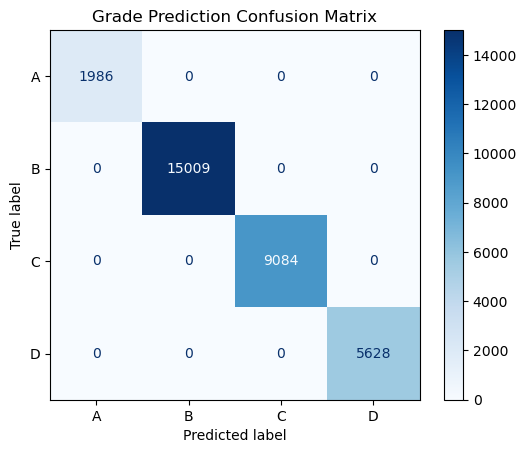

In [38]:
cm = confusion_matrix(y_test, y_pred_rf, labels = rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = rf.classes_)

disp.plot(cmap = plt.cm.Blues)
plt.title("Grade Prediction Confusion Matrix")
plt.show()

In [39]:
# create a dataframe of feature importances and their corresponding column names
importances_rf = pd.DataFrame({'Feature': X_train.columns, 'Importance': rf.feature_importances_})
importances_rf = importances_rf.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_rf)

                                              Feature    Importance
0                                           pct_white  8.074852e-02
1                                           pct_black  5.210672e-02
2                              Median value (dollars)  5.067645e-02
3   Median household income in the past 12 months ...  5.045293e-02
4                     Black or African American alone  4.713953e-02
..                                                ...           ...
78                           SqFtTotLiving_is_missing  2.192877e-16
79                                      is_industrial  1.557315e-16
80                       pct_two_plus_race_is_missing  0.000000e+00
81                         pct_amer_indian_is_missing  0.000000e+00
82                          pct_renter_occ_is_missing  0.000000e+00

[83 rows x 2 columns]
